# Phase 1 — Exploratory Data Analysis
## UCI Online Retail II — Customer Intelligence Project

**Goal of this phase:** understand the structure, scale, and quality of the raw data *before* any cleaning. We do not fix anything here — we explore and document every issue so Phase 2 (cleaning) has a clear checklist.

**Dataset:** Real transactions from a UK-based online retailer, Dec 2009 – Dec 2011.
**Source:** UCI Machine Learning Repository (dataset 502).

**Columns (Online Retail II schema):**
- `Invoice` — invoice number. Starts with **C** = cancellation.
- `StockCode` — product code.
- `Description` — product name.
- `Quantity` — units per transaction line. Can be negative (returns/cancellations).
- `InvoiceDate` — timestamp.
- `Price` — unit price in GBP.
- `Customer ID` — customer identifier. Often missing.
- `Country` — customer country.


## 1. Imports & Settings

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Locate the repo root portably by walking up from the current working
# directory until the 'data' folder is found, so the notebook runs on any
# machine and from any subfolder.
def find_project_root(marker='data'):
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).is_dir():
            return parent
    raise FileNotFoundError(
        f"Could not find project root: no '{marker}/' folder above {Path.cwd()}. "
        "Run this notebook from inside the cloned repository."
    )

PROJECT_ROOT = find_project_root()
RAW_PATH  = str(PROJECT_ROOT / 'data' / 'raw' / 'online_retail_II.xlsx')
DOCS_PATH = str(PROJECT_ROOT / 'docs')
os.makedirs(DOCS_PATH, exist_ok=True)

## 2. Load the Data

The Excel file has **two sheets** — one per year. We load both and concatenate into a single dataframe.

> `openpyxl` is required to read `.xlsx`. If you get an error, run `pip install openpyxl` in your terminal.

In [18]:
# Inspect available sheet names first
xls = pd.ExcelFile(RAW_PATH)
print('Sheets found:', xls.sheet_names)

Sheets found: ['Year 2009-2010', 'Year 2010-2011']


In [19]:
# Load both sheets and combine
df_list = [pd.read_excel(RAW_PATH, sheet_name=s) for s in xls.sheet_names]
df = pd.concat(df_list, ignore_index=True)

print(f'Combined shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')

Combined shape: 1,067,371 rows  x  8 columns


In [20]:
# Reproducibility check: confirm the exact raw file is present and record its
# checksum. If a reviewer's file differs, the figures in this notebook will not
# match — this surfaces that immediately rather than failing silently.
import hashlib

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

print('Raw data checksum (SHA-256, first 12 chars):')
print(f'  online_retail_II.xlsx   {sha256(RAW_PATH)[:12]}')

Raw data checksum (SHA-256, first 12 chars):
  online_retail_II.xlsx   bcbe73b35f5b


## 3. First Look

In [21]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,"13,085.00",United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,"13,085.00",United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,"13,085.00",United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,"13,085.00",United Kingdom


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [23]:
# Standardise column names to make later code cleaner (snake_case, no spaces)
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_'))
df.columns.tolist()

['invoice',
 'stockcode',
 'description',
 'quantity',
 'invoicedate',
 'price',
 'customer_id',
 'country']

## 4. Date Range & Scale

How much history do we have, and how many unique invoices, products, and customers?

In [24]:
print('Date range :', df['invoicedate'].min(), '->', df['invoicedate'].max())
print(f"Invoices   : {df['invoice'].nunique():,}")
print(f"Products   : {df['stockcode'].nunique():,}")
print(f"Customers  : {df['customer_id'].nunique():,}")
print(f"Countries  : {df['country'].nunique():,}")

Date range : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Invoices   : 53,628
Products   : 5,305
Customers  : 5,942
Countries  : 43


## 5. Descriptive Statistics

In [25]:
df.describe()

,quantity,invoicedate,price,customer_id
count,"1,067,371.00",1067371,"1,067,371.00","824,364.00"
mean,9.94,2011-01-02 21:13:55.394029,4.65,"15,324.64"
min,"-80,995.00",2009-12-01 07:45:00,"-53,594.36","12,346.00"
25%,1.00,2010-07-09 09:46:00,1.25,"13,975.00"
50%,3.00,2010-12-07 15:28:00,2.10,"15,255.00"
75%,10.00,2011-07-22 10:23:00,4.15,"16,797.00"
max,"80,995.00",2011-12-09 12:50:00,"38,970.00","18,287.00"
std,172.71,NaN,123.55,"1,697.46"


Watch the `quantity` and `price` columns above — the min values will likely be negative or zero. That's our first data-quality signal.

## 6. Missing Values

Which columns have nulls, and how severe?

In [26]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table[missing_table['missing_count'] > 0].sort_values('missing_count', ascending=False)

,missing_count,missing_pct
customer_id,243007,22.77
description,4382,0.41


**Why this matters:** `customer_id` is the most important column for RFM, CLV, and cohort analysis. Any row without it cannot be tied to a customer. We will quantify exactly how many rows that affects.

## 7. Data Quality Issues to Flag for Phase 2

We check each issue, count it, but **do not remove anything yet**.

In [27]:
# 7a. Cancellations — invoices starting with 'C'
cancellations = df[df['invoice'].astype(str).str.startswith('C')]
print(f"Cancellation rows : {len(cancellations):,} ({len(cancellations)/len(df)*100:.2f}%)")

Cancellation rows : 19,494 (1.83%)


In [28]:
# 7b. Negative or zero quantity
neg_qty = df[df['quantity'] <= 0]
print(f"Quantity <= 0     : {len(neg_qty):,} ({len(neg_qty)/len(df)*100:.2f}%)")

# 7c. Negative or zero price
neg_price = df[df['price'] <= 0]
print(f"Price <= 0        : {len(neg_price):,} ({len(neg_price)/len(df)*100:.2f}%)")

# 7d. Missing customer ID
no_cust = df[df['customer_id'].isnull()]
print(f"Missing customer  : {len(no_cust):,} ({len(no_cust)/len(df)*100:.2f}%)")

# 7e. Duplicate rows
dupes = df.duplicated().sum()
print(f"Exact duplicates  : {dupes:,} ({dupes/len(df)*100:.2f}%)")

Quantity <= 0     : 22,950 (2.15%)
Price <= 0        : 6,207 (0.58%)
Missing customer  : 243,007 (22.77%)
Exact duplicates  : 34,335 (3.22%)


## 8. Exploratory Views

A few quick charts to understand the business before cleaning. Note: these include the dirty data, so treat them as directional, not final.

In [29]:
# Add a revenue column for exploration (quantity * price)
df['revenue'] = df['quantity'] * df['price']

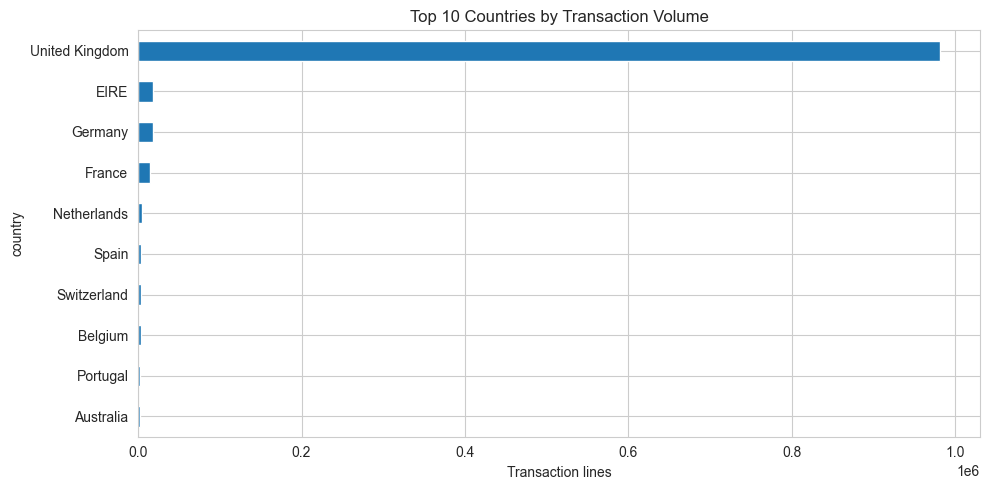

In [30]:
# Top 10 countries by number of transaction lines
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='barh')
plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Transaction lines')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

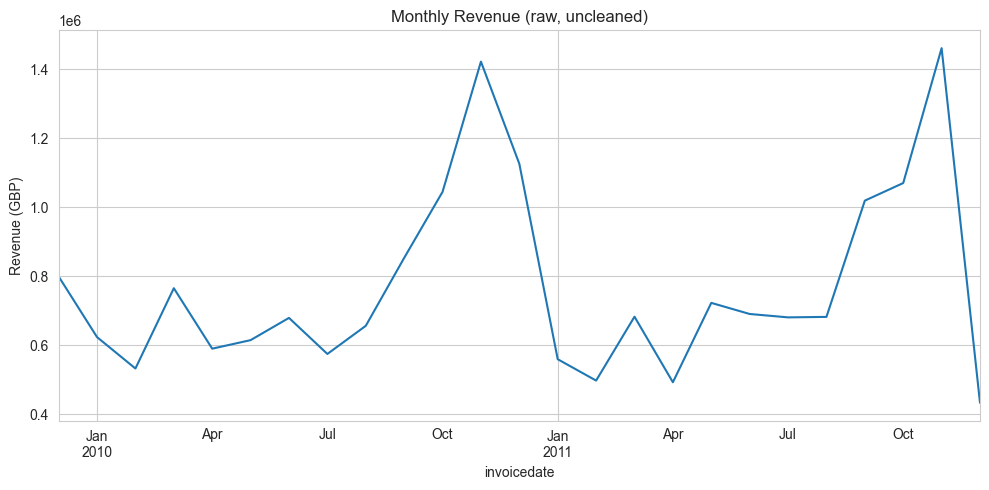

In [31]:
# Revenue over time (monthly) — directional only
monthly = (df.set_index('invoicedate')
             .resample('ME')['revenue']
             .sum())
monthly.plot()
plt.title('Monthly Revenue (raw, uncleaned)')
plt.ylabel('Revenue (GBP)')
plt.tight_layout()
plt.show()

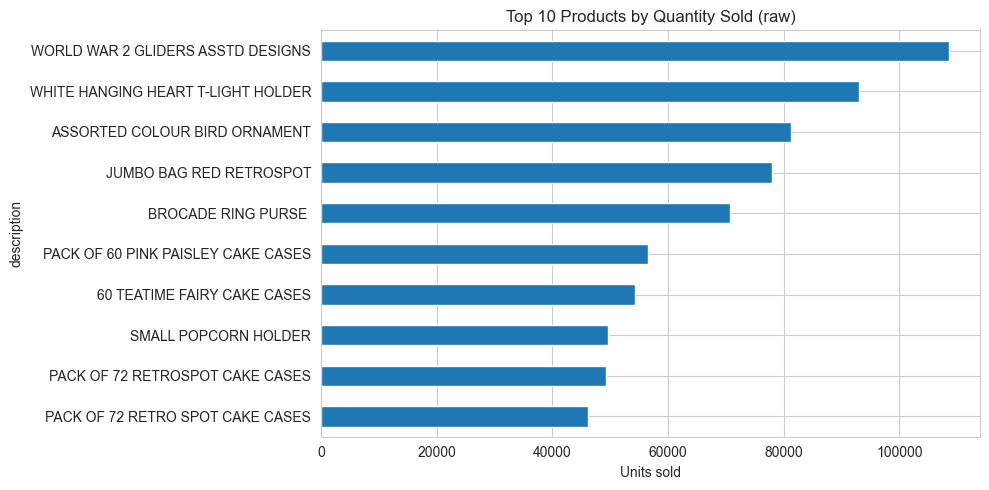

In [32]:
# Top 10 products by quantity sold
top_products = (df.groupby('description')['quantity']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))
top_products.plot(kind='barh')
plt.title('Top 10 Products by Quantity Sold (raw)')
plt.xlabel('Units sold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()